# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/imnotparama/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
print("Working dir:", os.getcwd())

Working dir: /content/flyrank-ml-internship


**Question:** Which pages should a content team review first for refresh,
given limited weekly review bandwidth? This supports the decision:
where to spend a content/SEO team's next sprint. The action: a ranked
review queue with reason codes. The cost of a wrong call: false
positives waste reviewer hours; false negatives let real decline
compound unaddressed.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [2]:
import pandas as pd
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape)

(30000, 44)


**Data:** Starter dataset (data/raw/content_refresh_anonymized.csv),
30,000 rows, one row per pseudonymized content item, 32 clients,
trailing-90-day metrics. Also verified a mid-panel warehouse slice
(March 2026, 9,841,378 rows) from the full FlyRank internship warehouse
release via DuckDB, confirming grain and availability.

**Excluded:** trend_direction and trend_pct (label-derived, would leak
the answer); any FlyRank product decision flags (health_score,
priority_score — not shipped, and wouldn't be used even if rebuilt);
GA4-derived features for rows without ga4_data_available = TRUE (only
~4.2% of a sampled month had GA4 coverage).

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [3]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit

df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)
features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count", "search_volume"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"]
groups = df["client_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
print(f"Train: {len(train_idx)} rows / Test: {len(test_idx)} rows, {df['client_id'].iloc[test_idx].nunique()} held-out clients")

Train: 22885 rows / Test: 7115 rows, 8 held-out clients


**Label:** is_declining_label = (trend_direction == "down"), a proxy,
not a validated future outcome.

**Baseline:** stale_visible_page rule — days_since_last_update >= 180
AND impressions_90d >= 100, scored by impressions_90d.

**Model:** Random Forest and Logistic Regression, 7 observable
features, compared to the baseline on the same metric: Precision@50.

**Validation:** Grouped split by client_id (not random) — no client's
pages appear in both train and test, since a random split let scores
inflate via client memorization (see Results).

**Leakage checks:** trend_pct/trend_direction excluded as features.
Deliberately added trend_pct as a test — score jumped to 1.000,
confirming the harness detects leakage; removed for the real model.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [4]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

test_df = df.iloc[test_idx].copy()
test_df["baseline_score"] = (
    (test_df["days_since_last_update"] >= 180).astype(int) *
    (test_df["impressions_90d"] >= 100).astype(int) * test_df["impressions_90d"]
)
baseline_p50 = precision_at_k(test_df["baseline_score"], y.iloc[test_idx], 50)

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf.fit(X.iloc[train_idx], y.iloc[train_idx])
rf_p50 = precision_at_k(rf.predict_proba(X.iloc[test_idx])[:, 1], y.iloc[test_idx], 50)

logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
logreg.fit(X.iloc[train_idx], y.iloc[train_idx])
logreg_p50 = precision_at_k(logreg.predict_proba(X.iloc[test_idx])[:, 1], y.iloc[test_idx], 50)

results = pd.DataFrame({
    "Method": ["Base rate", "Baseline rule", "Random Forest", "Logistic Regression"],
    "Precision@50": [y.iloc[test_idx].mean(), baseline_p50, rf_p50, logreg_p50]
})
print(results)

                Method  Precision@50
0            Base rate      0.516514
1        Baseline rule      0.620000
2        Random Forest      0.580000
3  Logistic Regression      0.660000


**Results:** On the grouped-by-client split (8 held-out clients),
Logistic Regression (0.660) and the baseline rule (0.620) both
outperformed Random Forest (0.580), against a base rate of 0.517. Under
a naive random split, Random Forest's score inflated to 0.920 — a
34-point gap explained entirely by client leakage. The grouped number
is the honest one.

## 5. Limitations

*What this work cannot claim.*

Proxy label, not a validated future outcome. Single-split observation
(random_state=42) — a different seed or larger held-out client set
could shift rankings. Sparse GA4 coverage (~4.2% in a sampled month).
Cross-sectional/observational data — no claim that refreshing a page
causes recovery. No claim about Google's ranking algorithm.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [6]:
def assign_reason_code(row):
    if row["model_score"] >= 0.65:
        return "model_decline_risk"
    elif row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 100:
        return "stale_visible_page"
    elif row["impressions_90d"] >= 500 and row["avg_position"] > 0 and row["avg_position"] <= 20 and row["ctr"] < 0.5:
        return "ctr_review_candidate"
    else:
        return "monitor_only"

test_df["model_score"] = rf.predict_proba(X.iloc[test_idx])[:, 1]
test_df["reason_code"] = test_df.apply(assign_reason_code, axis=1)
test_df["action"] = test_df["reason_code"].map({
    "model_decline_risk": "review_for_refresh",
    "stale_visible_page": "review_for_refresh",
    "ctr_review_candidate": "review_metadata_ctr",
    "monitor_only": "monitor"
})

ranked_queue = test_df.sort_values("model_score", ascending=False)[
    ["content_id", "model_score", "reason_code", "action",
     "days_since_last_update", "impressions_90d", "avg_position", "ctr", "trend_direction"]
]

os.makedirs("work/outputs", exist_ok=True)
ranked_queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Wrote {len(ranked_queue)} rows")
ranked_queue.head(20)

Wrote 7115 rows


,content_id,model_score,reason_code,action,days_since_last_update,impressions_90d,avg_position,ctr,trend_direction
18989,content_edf5b03b36aa,0.980,model_decline_risk,review_for_refresh,20,535,3.1,0.00,down
16667,content_720edd4e1491,0.975,model_decline_risk,review_for_refresh,104,1174,13.8,0.43,up
14343,content_9ac61c04930e,0.970,model_decline_risk,review_for_refresh,104,1828,5.6,0.22,down
7050,content_7a6cb4857fe6,0.970,model_decline_risk,review_for_refresh,20,789,1.6,0.00,down
22526,content_1d0963b56227,0.970,model_decline_risk,review_for_refresh,104,3445,39.0,0.09,up
6228,content_e988c1699454,0.965,model_decline_risk,review_for_refresh,104,2197,21.5,0.00,down
3329,content_eb3b2c3bbc34,0.965,model_decline_risk,review_for_refresh,20,580,1.3,0.00,down
22730,content_bb1edbf0ba6c,0.960,model_decline_risk,review_for_refresh,104,1290,12.4,0.00,down
21023,content_8a4f4f22c861,0.960,model_decline_risk,review_for_refresh,14,2055,25.4,0.15,stable
12246,content_c5cdd229c348,0.955,model_decline_risk,review_for_refresh,14,1531,22.0,0.00,down


**Ranked recommendations:** Each page in the review queue gets a
reason code (model_decline_risk, stale_visible_page, ctr_review_candidate,
monitor_only) and a mapped action. Human review is required before
acting — see limitations for why (the model can flag pages with a
stable or growing trend).

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

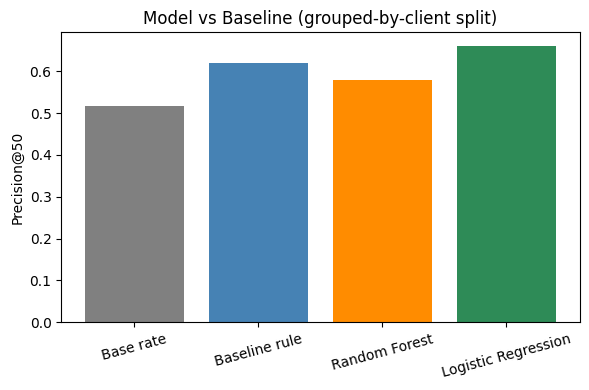

Saved work/figures/model_vs_baseline.png


In [5]:
import matplotlib.pyplot as plt
os.makedirs("work/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(results["Method"], results["Precision@50"], color=["gray","steelblue","darkorange","seagreen"])
ax.set_ylabel("Precision@50")
ax.set_title("Model vs Baseline (grouped-by-client split)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline.png", dpi=150)
plt.show()
print("Saved work/figures/model_vs_baseline.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.